In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib

In [2]:
import requests
import time

In [3]:
cities = {
    "Mumbai": (19.0760, 72.8777),
    "Delhi": (28.6139, 77.2090),
    "Chennai": (13.0827, 80.2707),
    "Kolkata": (22.5726, 88.3639),
    "Bengaluru": (12.9716, 77.5946)
}

start_date = "2021-01-01"
end_date = "2025-12-31"

In [4]:
all_data = []

for city, (latitude, longitude) in cities.items():

    print(f"Downloading data for {city}...")

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": (
            "temperature_2m,"
            "relative_humidity_2m,"
            "precipitation,"
            "surface_pressure,"
            "wind_speed_10m,"
            "wind_direction_10m"
        ),
        "timezone": "Asia/Kolkata"
    }

    response = requests.get(url, params=params)

    if response.status_code == 200:

        data = response.json()

        df = pd.DataFrame(data["hourly"])

        df["city"] = city

        all_data.append(df)

        print(f"✓ {city} downloaded successfully!")

    else:
        print(f"✗ Failed to download {city}")

    time.sleep(1)

✓ Mumbai downloaded successfully!
✓ Delhi downloaded successfully!
✓ Chennai downloaded successfully!
✓ Kolkata downloaded successfully!
✓ Bengaluru downloaded successfully!


In [5]:
weather_df = pd.concat(all_data, ignore_index=True)

print("Dataset shape:", weather_df.shape)

weather_df.head()

Dataset shape: (219120, 8)


,time,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m,city
0,2021-01-01T00:00,23.1,75,0.0,1010.8,10.2,352,Mumbai
1,2021-01-01T01:00,22.8,74,0.0,1010.5,7.2,360,Mumbai
2,2021-01-01T02:00,22.3,77,0.0,1009.8,6.2,350,Mumbai
3,2021-01-01T03:00,21.8,82,0.0,1009.6,4.7,351,Mumbai
4,2021-01-01T04:00,21.4,84,0.0,1009.5,4.7,9,Mumbai


In [6]:
weather_df.to_csv("aws_weather_data.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [7]:
from google.colab import files

files.download("aws_weather_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219120 entries, 0 to 219119
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   time                  219120 non-null  object 
 1   temperature_2m        219120 non-null  float64
 2   relative_humidity_2m  219120 non-null  int64  
 3   precipitation         219120 non-null  float64
 4   surface_pressure      219120 non-null  float64
 5   wind_speed_10m        219120 non-null  float64
 6   wind_direction_10m    219120 non-null  int64  
 7   city                  219120 non-null  object 
dtypes: float64(4), int64(2), object(2)
memory usage: 13.4+ MB


In [9]:
weather_df.describe()

,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m
count,219120.000000,219120.000000,219120.000000,219120.000000,219120.000000,219120.000000
mean,25.867843,71.175484,0.181521,983.513846,10.649996,189.870979
std,5.346595,20.502833,0.856848,37.350388,5.398763,101.434468
min,3.200000,4.000000,0.000000,902.600000,0.000000,0.000000
25%,22.800000,58.000000,0.000000,978.600000,6.600000,99.000000
50%,26.400000,76.000000,0.000000,1002.600000,9.800000,201.000000
75%,29.100000,88.000000,0.000000,1008.700000,13.900000,276.000000
max,46.000000,100.000000,35.700000,1021.200000,61.900000,360.000000


In [10]:
print(weather_df.isnull().sum())

time                    0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
surface_pressure        0
wind_speed_10m          0
wind_direction_10m      0
city                    0
dtype: int64


In [11]:
weather_df = weather_df.dropna()

print(weather_df.isnull().sum())

time                    0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
surface_pressure        0
wind_speed_10m          0
wind_direction_10m      0
city                    0
dtype: int64


In [12]:
features = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "surface_pressure",
    "wind_speed_10m",
    "wind_direction_10m"
]

X = weather_df[features]

X.head()

,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m
0,23.1,75,0.0,1010.8,10.2,352
1,22.8,74,0.0,1010.5,7.2,360
2,22.3,77,0.0,1009.8,6.2,350
3,21.8,82,0.0,1009.6,4.7,351
4,21.4,84,0.0,1009.5,4.7,9


In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling completed!")

print(X_scaled[:5])

Scaling completed!
[[-0.51768456  0.18653642 -0.21184808  0.73054707 -0.08335194  1.59836587]
 [-0.57379516  0.13776256 -0.21184808  0.72251501 -0.63903602  1.6772347 ]
 [-0.66731285  0.28408414 -0.21184808  0.70377353 -0.82426405  1.57864866]
 [-0.76083053  0.52795343 -0.21184808  0.69841882 -1.10210609  1.58850726]
 [-0.83564467  0.62550115 -0.21184808  0.69574146 -1.10210609 -1.78313542]]


In [14]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)

model.fit(X_scaled)

print("🎉 Model training completed!")

🎉 Model training completed!


In [15]:
weather_df["anomaly_prediction"] = model.predict(X_scaled)

In [16]:
weather_df["status"] = weather_df["anomaly_prediction"].map({
    1: "Normal",
    -1: "Anomaly"
})

weather_df[["status"]].value_counts()

,count
status,
Normal,216928
Anomaly,2192


In [17]:
anomalies = weather_df[
    weather_df["status"] == "Anomaly"
]

anomalies.head(20)

,time,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m,city,anomaly_prediction,status
3255,2021-05-16T15:00,36.2,38,0.2,995.9,25.3,79,Mumbai,-1,Anomaly
3267,2021-05-17T03:00,26.6,85,2.3,993.8,28.2,85,Mumbai,-1,Anomaly
3270,2021-05-17T06:00,26.3,84,3.5,992.8,31.8,96,Mumbai,-1,Anomaly
3271,2021-05-17T07:00,26.3,84,9.9,993.0,36.6,100,Mumbai,-1,Anomaly
3272,2021-05-17T08:00,26.6,88,6.2,993.9,38.0,121,Mumbai,-1,Anomaly
3273,2021-05-17T09:00,27.1,88,4.3,993.7,49.3,126,Mumbai,-1,Anomaly
3274,2021-05-17T10:00,26.8,90,4.3,994.6,53.3,138,Mumbai,-1,Anomaly
3275,2021-05-17T11:00,26.9,91,6.4,994.9,61.9,160,Mumbai,-1,Anomaly
3276,2021-05-17T12:00,26.9,89,7.5,995.3,55.6,163,Mumbai,-1,Anomaly
3277,2021-05-17T13:00,26.8,90,9.6,995.6,57.1,172,Mumbai,-1,Anomaly


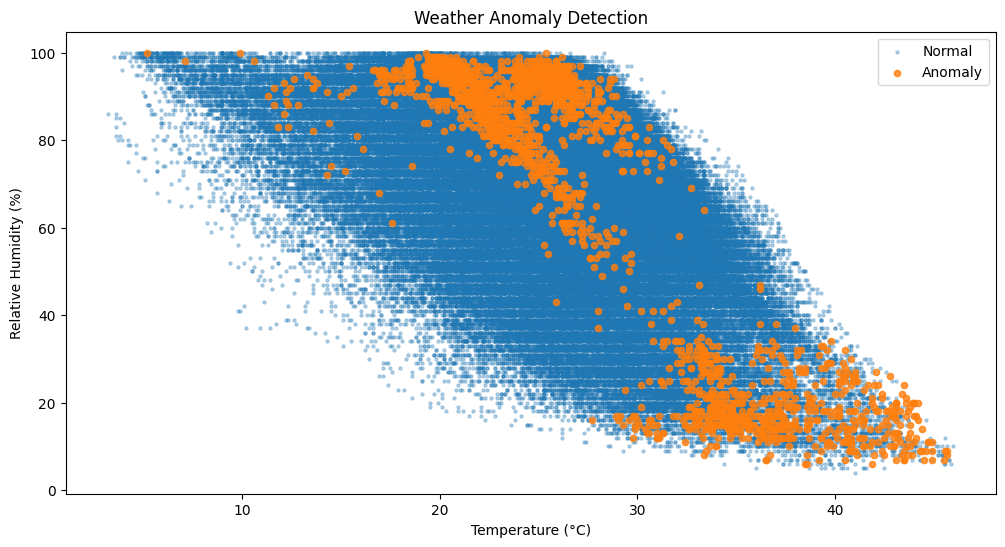

In [18]:
plt.figure(figsize=(12, 6))

normal = weather_df[
    weather_df["status"] == "Normal"
]

anomaly = weather_df[
    weather_df["status"] == "Anomaly"
]

plt.scatter(
    normal["temperature_2m"],
    normal["relative_humidity_2m"],
    s=5,
    alpha=0.3,
    label="Normal"
)

plt.scatter(
    anomaly["temperature_2m"],
    anomaly["relative_humidity_2m"],
    s=20,
    alpha=0.8,
    label="Anomaly"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.title("Weather Anomaly Detection")

plt.legend()

plt.show()

In [19]:
joblib.dump(model, "weather_anomaly_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [20]:
joblib.dump(scaler, "weather_scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


In [21]:
from google.colab import files

files.download("weather_anomaly_model.pkl")
files.download("weather_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
aws_test_df = weather_df.copy()

print("Original shape:", weather_df.shape)
print("Test dataset shape:", aws_test_df.shape)

Original shape: (219120, 10)
Test dataset shape: (219120, 10)


In [23]:
aws_test_df["injected_anomaly"] = 0

print(aws_test_df["injected_anomaly"].value_counts())

injected_anomaly
0    219120
Name: count, dtype: int64


In [24]:
np.random.seed(42)

num_anomalies = 1000

spike_indices = np.random.choice(
    aws_test_df.index,
    num_anomalies,
    replace=False
)

aws_test_df.loc[
    spike_indices,
    "temperature_2m"
] += np.random.uniform(20, 40, num_anomalies)

aws_test_df.loc[
    spike_indices,
    "injected_anomaly"
] = 1

print("Temperature spike anomalies added!")

Temperature spike anomalies added!


In [25]:
humidity_indices = np.random.choice(
    aws_test_df.index,
    1000,
    replace=False
)

aws_test_df.loc[
    humidity_indices,
    "relative_humidity_2m"
] -= np.random.uniform(30, 60, 1000)

aws_test_df.loc[
    humidity_indices,
    "relative_humidity_2m"
] = aws_test_df.loc[
    humidity_indices,
    "relative_humidity_2m"
].clip(lower=0)

aws_test_df.loc[
    humidity_indices,
    "injected_anomaly"
] = 1

print("Humidity drop anomalies added!")

Humidity drop anomalies added!


/tmp/ipykernel_2968/2325234972.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 16.48210266  31.76296276   9.62004255  28.41656915  21.8691472
  -7.312222    21.4544562   52.66344956  38.18584415  43.44825407
  41.45004706   1.13917653  53.67321509 -10.20281862  50.53142484
  48.4917782   61.03430702  -2.77284597  -6.75189304  46.00422527
  38.75864103  19.11022764  42.71444871  39.36304315 -15.24198128
  16.93822868  34.78264274  24.28788139  47.83826096  -9.14841085
  18.38565134  62.6866214   32.40267915  42.0852274   28.06664768
  30.70827461  62.53325325   2.59483068  26.42594911  32.29353749
  61.48939564  14.36236186  66.77322801  25.65347113  28.14763825
  49.22050469  34.22597408  58.70131319  11.75405918 -29.97203517
  31.47207918 -17.33455105  30.82852413  32.68816747  16.39495805
  59.66358316  20.67547829  48.63225875  55.02589554 -11.40078924
  -1.57376767   8.83767758  34.08798679  16

In [26]:
pressure_indices = np.random.choice(
    aws_test_df.index,
    1000,
    replace=False
)

aws_test_df.loc[
    pressure_indices,
    "surface_pressure"
] += np.random.uniform(100, 300, 1000)

aws_test_df.loc[
    pressure_indices,
    "injected_anomaly"
] = 1

print("Pressure anomalies added!")

Pressure anomalies added!


In [27]:
wind_indices = np.random.choice(
    aws_test_df.index,
    1000,
    replace=False
)

aws_test_df.loc[
    wind_indices,
    "wind_speed_10m"
] += np.random.uniform(100, 200, 1000)

aws_test_df.loc[
    wind_indices,
    "injected_anomaly"
] = 1

print("Wind anomalies added!")

Wind anomalies added!


In [28]:
print(
    aws_test_df["injected_anomaly"].value_counts()
)

injected_anomaly
0    215142
1      3978
Name: count, dtype: int64


In [29]:
aws_test_df.to_csv(
    "aws_weather_test_with_anomalies.csv",
    index=False
)

print("Test dataset saved!")

Test dataset saved!


In [30]:
aws_test_df["relative_humidity_2m"] = (
    aws_test_df["relative_humidity_2m"].astype(float)
)

In [31]:
X_test = aws_test_df[features]

X_test.head()

,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m
0,23.1,75.0,0.0,1010.8,10.2,352
1,22.8,74.0,0.0,1010.5,7.2,360
2,22.3,77.0,0.0,1009.8,6.2,350
3,21.8,82.0,0.0,1009.6,4.7,351
4,21.4,84.0,0.0,1009.5,4.7,9


In [32]:
X_test_scaled = scaler.transform(X_test)

print("Test data scaled successfully!")

Test data scaled successfully!


In [33]:
aws_test_df["model_prediction"] = model.predict(X_test_scaled)

In [34]:
aws_test_df["model_status"] = aws_test_df["model_prediction"].map({
    1: "Normal",
    -1: "Anomaly"
})

aws_test_df["model_status"].value_counts()

,count
model_status,
Normal,216631
Anomaly,2489


In [35]:
aws_test_df["model_anomaly"] = (
    aws_test_df["model_prediction"] == -1
).astype(int)

aws_test_df[[
    "injected_anomaly",
    "model_anomaly"
]].head()

,injected_anomaly,model_anomaly
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [36]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [37]:
y_true = aws_test_df["injected_anomaly"]

y_pred = aws_test_df["model_anomaly"]

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

Precision: 0.13218159903575732
Recall: 0.08270487682252388
F1 Score: 0.10174733261172104


In [38]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[212982   2160]
 [  3649    329]]


<Figure size 700x500 with 0 Axes>

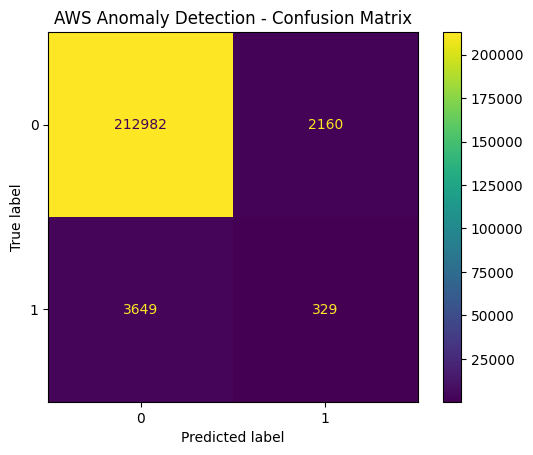

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("AWS Anomaly Detection - Confusion Matrix")

plt.show()

In [40]:
improved_df = weather_df.copy()

print(improved_df.shape)

(219120, 10)


In [41]:
improved_df["time"] = pd.to_datetime(improved_df["time"])

improved_df = improved_df.sort_values(
    ["city", "time"]
).reset_index(drop=True)

print("Time column prepared!")

Time column prepared!


In [42]:
base_features = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "surface_pressure",
    "wind_speed_10m",
    "wind_direction_10m"
]

for feature in base_features:
    improved_df[f"{feature}_change"] = (
        improved_df.groupby("city")[feature].diff()
    )

print("Change-based features created!")

Change-based features created!


In [43]:
improved_df.head()

,time,temperature_2m,relative_humidity_2m,precipitation,surface_pressure,wind_speed_10m,wind_direction_10m,city,anomaly_prediction,status,temperature_2m_change,relative_humidity_2m_change,precipitation_change,surface_pressure_change,wind_speed_10m_change,wind_direction_10m_change
0,2021-01-01 00:00:00,16.9,96,0.0,913.3,14.1,87,Bengaluru,1,Normal,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-01 01:00:00,16.7,98,0.0,912.8,14.2,83,Bengaluru,1,Normal,-0.2,2.0,0.0,-0.5,0.1,-4.0
2,2021-01-01 02:00:00,17.3,94,0.0,912.5,16.3,82,Bengaluru,1,Normal,0.6,-4.0,0.0,-0.3,2.1,-1.0
3,2021-01-01 03:00:00,17.5,92,0.0,912.1,16.5,80,Bengaluru,1,Normal,0.2,-2.0,0.0,-0.4,0.2,-2.0
4,2021-01-01 04:00:00,17.3,92,0.0,911.8,14.4,77,Bengaluru,1,Normal,-0.2,0.0,0.0,-0.3,-2.1,-3.0


In [44]:
improved_df = improved_df.dropna().reset_index(drop=True)

print("New shape:", improved_df.shape)

New shape: (219115, 16)


In [45]:
train_parts = []
test_parts = []

for city in improved_df["city"].unique():

    city_df = improved_df[
        improved_df["city"] == city
    ].copy()

    split_index = int(len(city_df) * 0.8)

    train_parts.append(city_df.iloc[:split_index])
    test_parts.append(city_df.iloc[split_index:])

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df = pd.concat(test_parts).reset_index(drop=True)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (175290, 16)
Testing shape: (43825, 16)


In [46]:
improved_features = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "surface_pressure",
    "wind_speed_10m",
    "wind_direction_10m",

    "temperature_2m_change",
    "relative_humidity_2m_change",
    "precipitation_change",
    "surface_pressure_change",
    "wind_speed_10m_change",
    "wind_direction_10m_change"
]

X_train = train_df[improved_features]

final_scaler = StandardScaler()

X_train_scaled = final_scaler.fit_transform(X_train)

final_model = IsolationForest(
    n_estimators=150,
    contamination=0.02,
    random_state=42
)

final_model.fit(X_train_scaled)

print("🎉 Improved AWS anomaly detection model trained!")

🎉 Improved AWS anomaly detection model trained!


In [47]:
final_test_df = test_df.copy()

final_test_df["injected_anomaly"] = 0

np.random.seed(42)

num_per_type = 500

In [48]:
indices = np.random.choice(
    final_test_df.index,
    num_per_type,
    replace=False
)

final_test_df.loc[indices, "temperature_2m"] += np.random.uniform(
    25, 45, num_per_type
)

final_test_df.loc[indices, "injected_anomaly"] = 1

In [49]:
indices = np.random.choice(
    final_test_df.index,
    num_per_type,
    replace=False
)

final_test_df["relative_humidity_2m"] = (
    final_test_df["relative_humidity_2m"].astype(float)
)

final_test_df.loc[indices, "relative_humidity_2m"] -= np.random.uniform(
    40, 70, num_per_type
)

final_test_df["relative_humidity_2m"] = (
    final_test_df["relative_humidity_2m"].clip(lower=0)
)

final_test_df.loc[indices, "injected_anomaly"] = 1

In [50]:
indices = np.random.choice(
    final_test_df.index,
    num_per_type,
    replace=False
)

final_test_df.loc[indices, "surface_pressure"] += np.random.uniform(
    100, 300, num_per_type
)

final_test_df.loc[indices, "injected_anomaly"] = 1

In [51]:
indices = np.random.choice(
    final_test_df.index,
    num_per_type,
    replace=False
)

final_test_df.loc[indices, "wind_speed_10m"] += np.random.uniform(
    100, 200, num_per_type
)

final_test_df.loc[indices, "injected_anomaly"] = 1

In [52]:
print(final_test_df["injected_anomaly"].value_counts())

injected_anomaly
0    41865
1     1960
Name: count, dtype: int64


In [53]:
for feature in base_features:
    final_test_df[f"{feature}_change"] = (
        final_test_df.groupby("city")[feature].diff()
    )

final_test_df = final_test_df.dropna().reset_index(drop=True)

print(final_test_df.shape)

(43820, 17)


In [54]:
X_final_test = final_test_df[improved_features]

X_final_test_scaled = final_scaler.transform(X_final_test)

final_predictions = final_model.predict(
    X_final_test_scaled
)

final_test_df["model_anomaly"] = (
    final_predictions == -1
).astype(int)

print(
    final_test_df["model_anomaly"].value_counts()
)

model_anomaly
0    42654
1     1166
Name: count, dtype: int64


In [55]:
y_true_final = final_test_df["injected_anomaly"]
y_pred_final = final_test_df["model_anomaly"]

print("Precision:", precision_score(
    y_true_final,
    y_pred_final
))

print("Recall:", recall_score(
    y_true_final,
    y_pred_final
))

print("F1 Score:", f1_score(
    y_true_final,
    y_pred_final
))

Precision: 0.2504288164665523
Recall: 0.1489795918367347
F1 Score: 0.18682021753039027


In [56]:
final_cm = confusion_matrix(
    y_true_final,
    y_pred_final
)

print(final_cm)

[[40986   874]
 [ 1668   292]]


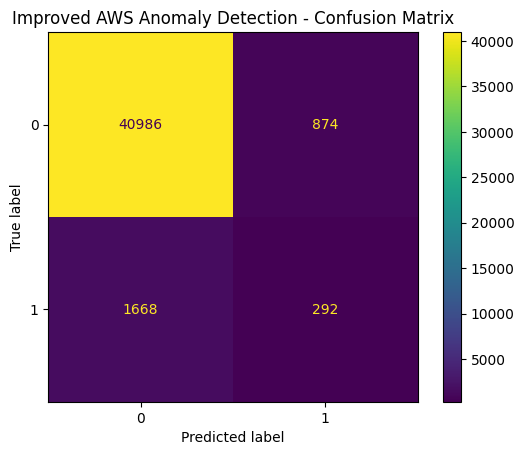

In [57]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm
)

disp.plot()

plt.title(
    "Improved AWS Anomaly Detection - Confusion Matrix"
)

plt.show()

In [58]:
joblib.dump(
    final_model,
    "final_aws_anomaly_model.pkl"
)

joblib.dump(
    final_scaler,
    "final_aws_scaler.pkl"
)

joblib.dump(
    improved_features,
    "final_aws_features.pkl"
)

print("🎉 FINAL MODEL SAVED!")

🎉 FINAL MODEL SAVED!


In [59]:
from google.colab import files

files.download("final_aws_anomaly_model.pkl")
files.download("final_aws_scaler.pkl")
files.download("final_aws_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
joblib.dump(final_model, "final_aws_anomaly_model.pkl")
joblib.dump(final_scaler, "final_aws_scaler.pkl")
joblib.dump(improved_features, "final_aws_features.pkl")

print("FINAL MODEL SAVED!")

FINAL MODEL SAVED!


In [61]:
print("Training dataframe:", train_df.shape if "train_df" in globals() else "Not found")
print("Test dataframe:", final_test_df.shape if "final_test_df" in globals() else "Not found")

print("\nAvailable important variables:")

variables_to_check = [
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "model",
    "scaler",
    "feature_columns",
    "final_test_df"
]

for var in variables_to_check:
    print(f"{var}: {'FOUND ✅' if var in globals() else 'NOT FOUND ❌'}")

Training dataframe: (175290, 16)
Test dataframe: (43820, 18)

Available important variables:
X_train: FOUND ✅
X_test: FOUND ✅
y_train: NOT FOUND ❌
y_test: NOT FOUND ❌
model: FOUND ✅
scaler: FOUND ✅
feature_columns: NOT FOUND ❌
final_test_df: FOUND ✅


In [62]:
print("TRAIN DATA COLUMNS:")
print(train_df.columns.tolist())

print("\nTEST DATA COLUMNS:")
print(final_test_df.columns.tolist())

print("\nMODEL TYPE:")
print(type(model))

print("\nTRAIN DATA SAMPLE:")
print(train_df.head())

TRAIN DATA COLUMNS:
['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'city', 'anomaly_prediction', 'status', 'temperature_2m_change', 'relative_humidity_2m_change', 'precipitation_change', 'surface_pressure_change', 'wind_speed_10m_change', 'wind_direction_10m_change']

TEST DATA COLUMNS:
['time', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'surface_pressure', 'wind_speed_10m', 'wind_direction_10m', 'city', 'anomaly_prediction', 'status', 'temperature_2m_change', 'relative_humidity_2m_change', 'precipitation_change', 'surface_pressure_change', 'wind_speed_10m_change', 'wind_direction_10m_change', 'injected_anomaly', 'model_anomaly']

MODEL TYPE:
<class 'sklearn.ensemble._iforest.IsolationForest'>

TRAIN DATA SAMPLE:
                 time  temperature_2m  relative_humidity_2m  precipitation  \
0 2021-01-01 01:00:00            16.7                    98            0.0   
1 2021-01-01 02:00:00   

In [63]:
feature_columns = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "surface_pressure",
    "wind_speed_10m",
    "wind_direction_10m",

    "temperature_2m_change",
    "relative_humidity_2m_change",
    "precipitation_change",
    "surface_pressure_change",
    "wind_speed_10m_change",
    "wind_direction_10m_change"
]

print("Number of features:", len(feature_columns))
print("\nFeatures used:")
for feature in feature_columns:
    print("-", feature)

Number of features: 12

Features used:
- temperature_2m
- relative_humidity_2m
- precipitation
- surface_pressure
- wind_speed_10m
- wind_direction_10m
- temperature_2m_change
- relative_humidity_2m_change
- precipitation_change
- surface_pressure_change
- wind_speed_10m_change
- wind_direction_10m_change


In [64]:
print("TRAIN anomaly_prediction:")
print(train_df["anomaly_prediction"].value_counts(dropna=False))

print("\nTRAIN status:")
print(train_df["status"].value_counts(dropna=False))

print("\nTEST injected_anomaly:")
print(final_test_df["injected_anomaly"].value_counts(dropna=False))

TRAIN anomaly_prediction:
anomaly_prediction
 1    173458
-1      1832
Name: count, dtype: int64

TRAIN status:
status
Normal     173458
Anomaly      1832
Name: count, dtype: int64

TEST injected_anomaly:
injected_anomaly
0    41860
1     1960
Name: count, dtype: int64


In [65]:
# Prepare test features using the same 12 features

X_final_test = final_test_df[feature_columns].copy()

# Scale the test data
X_final_test_scaled = scaler.transform(X_final_test)

# Get anomaly scores
# Lower scores = more anomalous
anomaly_scores = model.decision_function(X_final_test_scaled)

# Add scores to dataframe
final_test_df["anomaly_score"] = anomaly_scores

print("Anomaly score statistics:")
print(final_test_df["anomaly_score"].describe())

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- precipitation_change
- relative_humidity_2m_change
- surface_pressure_change
- temperature_2m_change
- wind_direction_10m_change
- ...
